# TOrderGenerator – Warehouse Fulfilment DES
### ME44305 · Systems Analysis & Simulation

**Doel:** Valideer de order-aankomstgenerator tegen Figure 5.2 (*Expected number of orders per hour*).

**Model:**
- Inter-arrival time per uur: $\text{IAT}_h \sim \text{Uniform}\left(0,\; \frac{2 \cdot 60}{\lambda_h}\right)$ minuten
- Elke order krijgt een wall-clock timestamp (`HH:MM:SS`)
- Simulatiehorizon: 24 uur | Warm-up: 30 min | Replicaties: 10


## 1 · Imports

In [1]:
import salabim as sim
sim.yieldless(False)
import random, statistics
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})

## 2 · Parameters
Verwachte orders per uur afgelezen van **Figure 5.2**.

In [2]:
# Expected orders per hour — Figure 5.2
ORDERS_PER_HOUR = [
    13.0,  7.5,  5.0,  4.5,  4.0,  4.0,   # 00-05
     5.0,  8.0, 16.0, 24.0, 30.0, 32.0,   # 06-11
    29.5, 32.0, 32.0, 32.0, 32.5, 30.0,   # 12-17
    28.0, 30.0, 30.5, 30.5, 28.0, 21.0,   # 18-23
]
assert len(ORDERS_PER_HOUR) == 24

TOTAL_ORDERS_PER_DAY = sum(ORDERS_PER_HOUR)


ITEMS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]

# Run configuration (section 5.3)
SIM_START_HOUR = 0       # start at 00:00
WARMUP_MIN     = 30      # warm-up period [min]
HORIZON_MIN    = 24 * 60 # observation horizon [min]
TOTAL_MIN      = WARMUP_MIN + HORIZON_MIN
N_REPS         = 10

print(f"Total expected orders/day (Fig 5.2): {TOTAL_ORDERS_PER_DAY:.0f}")
print(f"Simulation total time:               {TOTAL_MIN} min ({TOTAL_MIN/60:.1f} h)")

Total expected orders/day (Fig 5.2): 509
Simulation total time:               1470 min (24.5 h)


## 3 · Hulpfuncties

In [3]:
def sim_time_to_wallclock(sim_minute: float) -> str:
    """Converteer simulatieminuten naar HH:MM:SS wall-clock."""
    total_seconds = int(sim_minute * 60)
    h = (SIM_START_HOUR + total_seconds // 3600) % 24
    m = (total_seconds % 3600) // 60
    s = total_seconds % 60
    return f"{h:02d}:{m:02d}:{s:02d}"

def mean_iat_minutes(sim_minute: float) -> float:
    """Gemiddelde inter-arrival time [min] voor huidig tijdstip."""
    real_hour = int(SIM_START_HOUR + sim_minute // 60) % 24
    lam = ORDERS_PER_HOUR[real_hour]
    return 60.0 / lam if lam > 0 else 60.0

# Snelle test
print(sim_time_to_wallclock(125.75))   # verwacht: 02:05:45
print(f"mean IAT om 11:00 = {mean_iat_minutes(11*60):.2f} min")

02:05:45
mean IAT om 11:00 = 1.88 min


## 4 · Simulatieklassen
### 4.1 Passieve entiteit: `TOrder`

In [4]:
class TOrder:
    _next_id = 1

    def __init__(self, arrival_sim_min: float, item):
        self.order_id    = TOrder._next_id
        TOrder._next_id += 1
        self.arrival_min = arrival_sim_min
        self.timestamp   = sim_time_to_wallclock(arrival_sim_min)
        self.status      = "PENDING"
        self.item        = item

    def __repr__(self):
        return f"Order#{self.order_id:04d}  ts={self.timestamp}  status={self.status}  item={self.item}"

### 4.2 Actief proces: `TOrderGenerator`

In [5]:
class TOrderGenerator(sim.Component):
    def __init__(self, env, items, **kwargs):
        super().__init__(env=env, **kwargs)
        self.env    = env
        self.items = items
        self.orders = []

    def process(self):
        while True:
            mean_iat = mean_iat_minutes(self.env.now())
            iat = sim.Exponential(mean_iat).sample()  # IAT ~ Exponential(μ)
            yield self.hold(iat)
            item = random.choice(self.items) 
            order = TOrder(arrival_sim_min=self.env.now(), item=item)
            self.orders.append(order)

## 5 · Replicatiefunctie

In [6]:
def run_replication(seed: int) -> dict:
    TOrder._next_id = 1
    random.seed(seed)

    env = sim.Environment(trace=False, random_seed=seed)
    gen = TOrderGenerator(env=env, items = ITEMS, name="OrderGenerator")
    env.run(till=TOTAL_MIN)

    # Uurtelling — alleen observatieperiode (na warm-up)
    hourly = [0] * 24
    obs_orders = []
    for o in gen.orders:
        if o.arrival_min >= WARMUP_MIN:
            real_hour = int(SIM_START_HOUR + o.arrival_min // 60) % 24
            hourly[real_hour] += 1
            obs_orders.append(o)

    return {"total": len(obs_orders), "hourly": hourly, "orders": obs_orders}

## 6 · Uitvoeren — 10 replicaties

In [7]:
results = []
print(f"{'Rep':>4}  {'Total':>6}  Eerste 6 timestamps")
print("-" * 60)
for rep in range(1, N_REPS + 1):
    r = run_replication(seed=rep * 42)
    results.append(r)
    sample = "  ".join(o.timestamp for o in r["orders"][:6])
    print(f"  {rep:2d}   {r['total']:5d}   {sample}")

obs_counts = [r["total"] for r in results]
mean_obs   = statistics.mean(obs_counts)
stdev_obs  = statistics.stdev(obs_counts)
ci_half    = 1.96 * stdev_obs / N_REPS**0.5

print("-" * 60)
print(f"\nGemiddeld gegenereerde orders : {mean_obs:.1f}")
print(f"Theoretisch verwacht (Fig 5.2): {TOTAL_ORDERS_PER_DAY:.1f}")
print(f"Relatieve fout                : {abs(mean_obs - TOTAL_ORDERS_PER_DAY)/TOTAL_ORDERS_PER_DAY*100:.1f}%")
print(f"95% CI half-width             : ±{ci_half:.1f}")

 Rep   Total  Eerste 6 timestamps
------------------------------------------------------------
   1     500   00:34:18  00:37:56  00:40:42  00:48:21  00:54:54  01:00:26
   2     504   00:38:37  00:40:01  00:42:22  00:44:13  00:44:50  00:45:03
   3     525   00:34:51  00:35:17  00:36:54  00:38:57  00:42:08  00:44:37
   4     485   00:32:11  00:34:09  00:47:30  00:56:47  01:23:17  01:28:08
   5     517   00:34:58  00:43:41  00:47:13  00:47:52  01:01:00  01:12:57
   6     496   00:30:00  00:37:47  00:38:17  00:42:29  00:45:36  00:52:53
   7     500   00:32:06  00:41:13  00:42:36  00:45:22  00:46:13  00:55:07
   8     495   00:31:05  00:37:40  00:40:51  00:48:10  00:58:53  01:19:20
   9     500   00:30:30  00:30:32  00:42:15  00:49:33  00:54:27  01:06:00
  10     505   00:46:05  00:52:45  00:53:23  01:11:42  01:12:45  01:15:18
------------------------------------------------------------

Gemiddeld gegenereerde orders : 502.7
Theoretisch verwacht (Fig 5.2): 509.0
Relatieve fout             

## 7 · Uurlijkse validatie

In [8]:
hourly_matrix = np.array([r["hourly"] for r in results], dtype=float)
h_means = hourly_matrix.mean(axis=0)
h_std   = hourly_matrix.std(axis=0, ddof=1)

print(f"{'Uur':>5}  {'Sim gem':>8}  {'Fig 5.2':>8}  {'Fout %':>7}  {'Std':>6}")
print("-" * 42)
for h in range(24):
    err = abs(h_means[h] - ORDERS_PER_HOUR[h]) / ORDERS_PER_HOUR[h] * 100
    flag = " ✓" if err < 10 else " !"
    print(f"  {h:02d}:00  {h_means[h]:8.1f}  {ORDERS_PER_HOUR[h]:8.1f}  {err:7.1f}%  {h_std[h]:6.1f}{flag}")

  Uur   Sim gem   Fig 5.2   Fout %     Std
------------------------------------------
  00:00      11.3      13.0     13.1%     2.9 !
  01:00       9.6       7.5     28.0%     2.2 !
  02:00       5.7       5.0     14.0%     2.6 !
  03:00       3.8       4.5     15.6%     1.6 !
  04:00       4.4       4.0     10.0%     2.1 !
  05:00       4.8       4.0     20.0%     1.5 !
  06:00       4.8       5.0      4.0%     1.9 ✓
  07:00       6.4       8.0     20.0%     2.4 !
  08:00      13.6      16.0     15.0%     4.0 !
  09:00      24.4      24.0      1.7%     3.9 ✓
  10:00      29.8      30.0      0.7%     7.3 ✓
  11:00      34.3      32.0      7.2%     3.5 ✓
  12:00      27.1      29.5      8.1%     4.4 ✓
  13:00      31.7      32.0      0.9%     4.6 ✓
  14:00      32.6      32.0      1.9%     3.9 ✓
  15:00      30.2      32.0      5.6%     8.4 ✓
  16:00      30.8      32.5      5.2%     6.5 ✓
  17:00      29.8      30.0      0.7%     4.2 ✓
  18:00      30.4      28.0      8.6%     4.2 ✓
  

## 8 · Grafieken

### 8.1 Simulated vs Figure 5.2 (alle 24 uur)

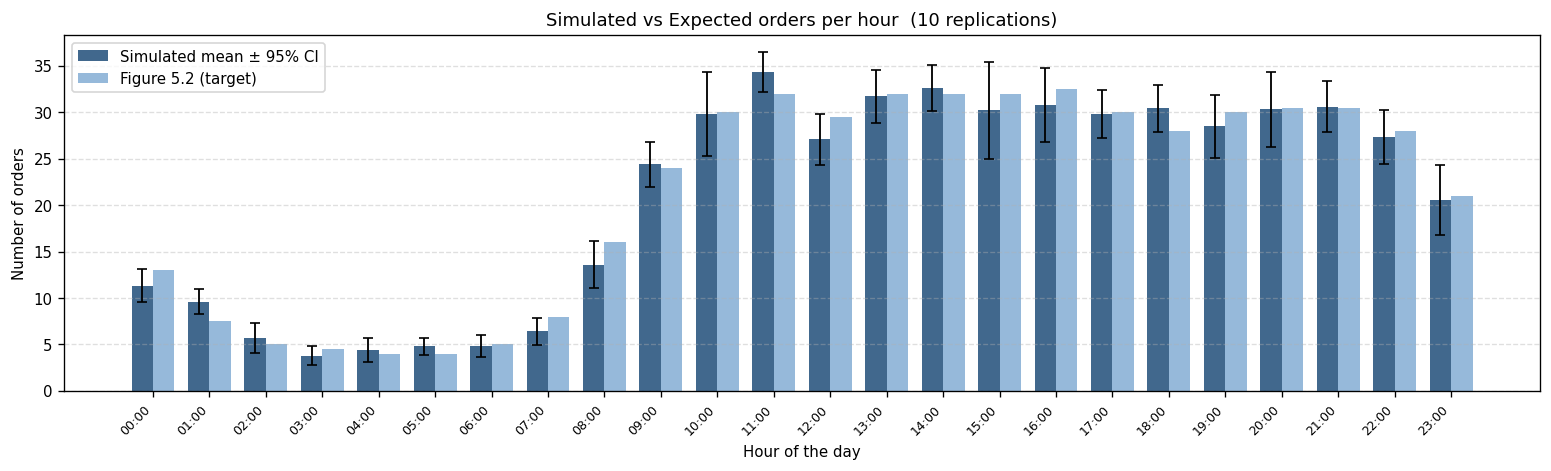

In [9]:
hourly_matrix = np.array([r["hourly"] for r in results], dtype=float)
h_mean = hourly_matrix.mean(axis=0)
h_std  = hourly_matrix.std(axis=0, ddof=1)
ci95   = 1.96 * h_std / np.sqrt(N_REPS)
theory = np.array(ORDERS_PER_HOUR)
hours  = np.arange(24)

fig, ax = plt.subplots(figsize=(13, 4))
w = 0.38
b1 = ax.bar(hours - w/2, h_mean, w, label="Simulated mean ± 95% CI",
            color="#1f4e79", alpha=0.85)
b2 = ax.bar(hours + w/2, theory, w, label="Figure 5.2 (target)",
            color="#2e75b6", alpha=0.50)
ax.errorbar(hours - w/2, h_mean, yerr=ci95,
            fmt="none", color="black", capsize=3, linewidth=1.1)
ax.set_xticks(hours)
ax.set_xticklabels([f"{h:02d}:00" for h in hours], rotation=45, ha="right", fontsize=7.5)
ax.set_xlabel("Hour of the day")
ax.set_ylabel("Number of orders")
ax.set_title("Simulated vs Expected orders per hour  (10 replications)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### 8.2 Order timestamps — replicatie 1

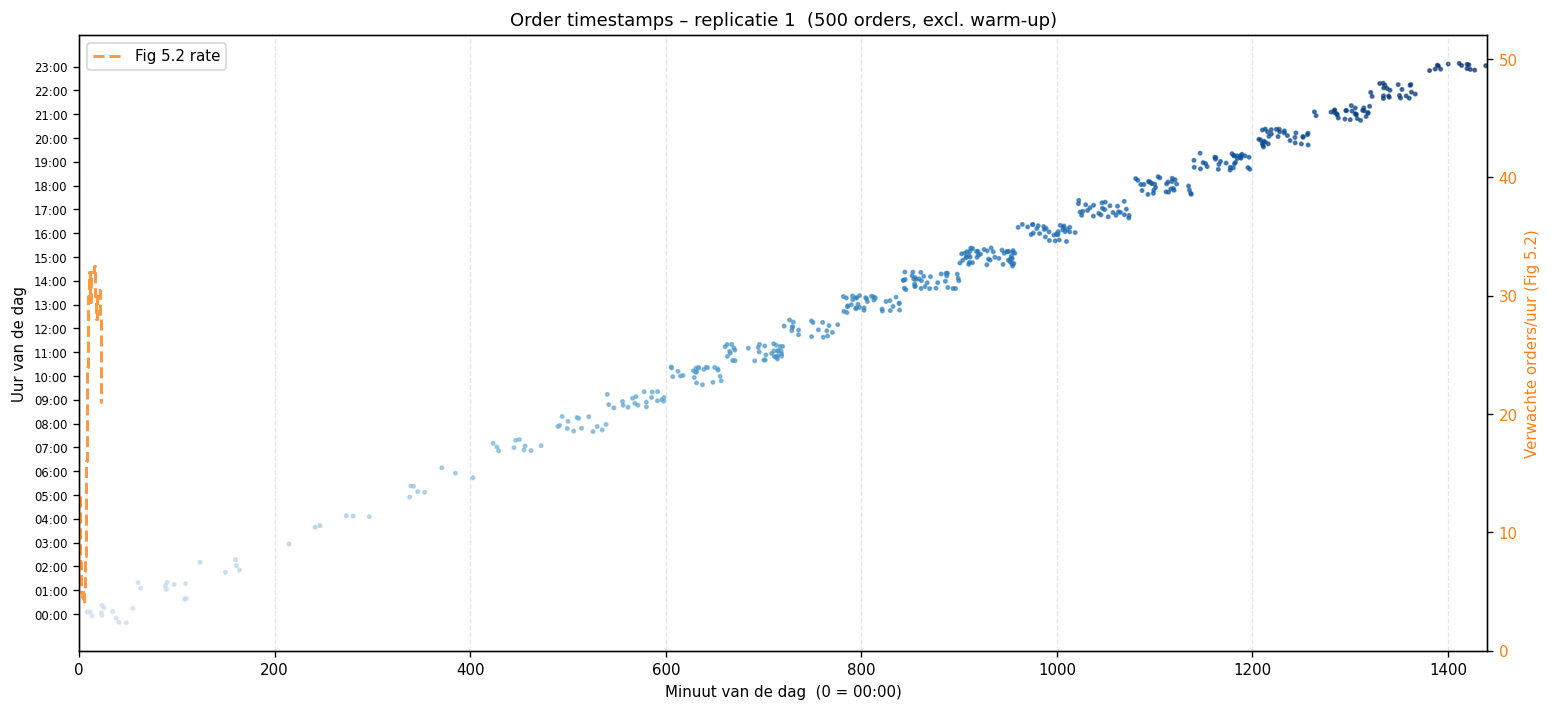

In [10]:
rep = results[0]
rng = np.random.default_rng(0)

scatter_x, scatter_y, col = [], [], []
for o in rep["orders"]:
    h  = int(o.timestamp[:2])
    mo = h * 60 + int(o.timestamp[3:5]) + int(o.timestamp[6:8]) / 60
    scatter_x.append(mo)
    scatter_y.append(h + rng.uniform(-0.38, 0.38))
    col.append(h / 23)

fig, ax = plt.subplots(figsize=(13, 6))
sc = ax.scatter(scatter_x, scatter_y, s=4, c=col, cmap="Blues",
                alpha=0.65, vmin=-0.3, vmax=1.0)

# Figure 5.2 rate overlay (rechter y-as)
ax2 = ax.twinx()
ax2.step(hours, theory, where="mid", color="#ff7f0e",
         linewidth=1.8, linestyle="--", alpha=0.8, label="Fig 5.2 rate")
ax2.set_ylabel("Verwachte orders/uur (Fig 5.2)", color="#ff7f0e")
ax2.tick_params(axis="y", labelcolor="#ff7f0e")
ax2.set_ylim(0, max(theory) * 1.6)
ax2.legend(loc="upper left")

ax.set_yticks(range(24))
ax.set_yticklabels([f"{h:02d}:00" for h in range(24)], fontsize=7)
ax.set_xlabel("Minuut van de dag  (0 = 00:00)")
ax.set_ylabel("Uur van de dag")
ax.set_title(f"Order timestamps – replicatie 1  ({len(scatter_x)} orders, excl. warm-up)")
ax.set_xlim(0, 1440)
ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

### 8.3 Totaal orders per replicatie

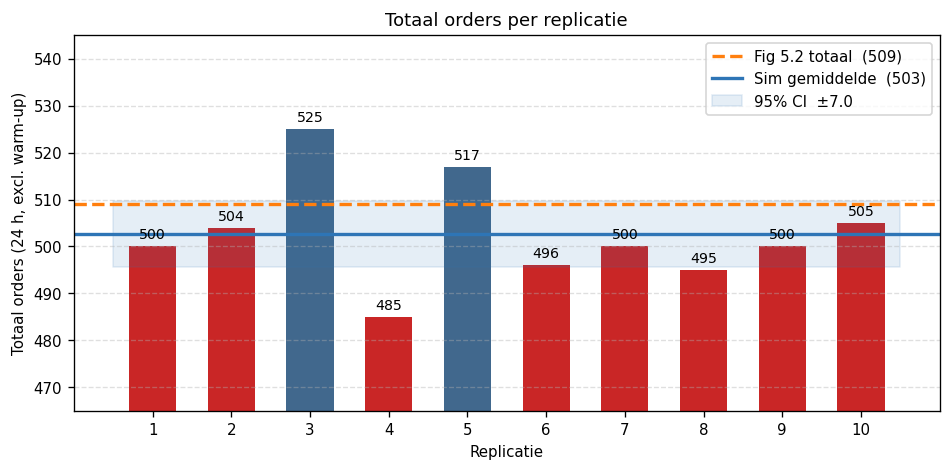

In [11]:
obs_counts = [r["total"] for r in results]
mean_obs   = statistics.mean(obs_counts)
stdev_obs  = statistics.stdev(obs_counts)
ci_half    = 1.96 * stdev_obs / N_REPS**0.5

fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["#1f4e79" if n >= TOTAL_ORDERS_PER_DAY else "#c00000" for n in obs_counts]
bars = ax.bar(range(1, N_REPS + 1), obs_counts, color=bar_colors, alpha=0.85, width=0.6)

ax.axhline(TOTAL_ORDERS_PER_DAY, color="#ff7f0e", linewidth=2, linestyle="--",
           label=f"Fig 5.2 totaal  ({TOTAL_ORDERS_PER_DAY:.0f})")
ax.axhline(mean_obs, color="#2e75b6", linewidth=2,
           label=f"Sim gemiddelde  ({mean_obs:.0f})")
ax.fill_between([0.5, N_REPS + 0.5], mean_obs - ci_half, mean_obs + ci_half,
                color="#2e75b6", alpha=0.12, label=f"95% CI  ±{ci_half:.1f}")

for bar, val in zip(bars, obs_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha="center", va="bottom", fontsize=8.5)

ax.set_xticks(range(1, N_REPS + 1))
ax.set_xlabel("Replicatie")
ax.set_ylabel("Totaal orders (24 h, excl. warm-up)")
ax.set_title("Totaal orders per replicatie")
ax.set_ylim(min(obs_counts) - 20, max(obs_counts) + 20)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## 9 · Voorbeeld orderlijst (replicatie 1, eerste 20 orders)

In [12]:
print(f"{'#Order ID':>6}  {'Timestamp':>10}    {'Status'}    {'Item ID'}")
print("-" * 42)
for o in results[0]["orders"][:20]:
    print(f"  {o.order_id:04d}       {o.timestamp}    {o.status}    {o.item}")

#Order ID   Timestamp    Status    Item ID
------------------------------------------
  0010       00:34:18    PENDING    23
  0011       00:37:56    PENDING    8
  0012       00:40:42    PENDING    9
  0013       00:48:21    PENDING    1
  0014       00:54:54    PENDING    6
  0015       01:00:26    PENDING    11
  0016       01:03:02    PENDING    7
  0017       01:28:15    PENDING    11
  0018       01:29:07    PENDING    13
  0019       01:29:56    PENDING    12
  0020       01:37:20    PENDING    2
  0021       01:47:48    PENDING    18
  0022       01:48:52    PENDING    13
  0023       01:49:31    PENDING    10
  0024       02:03:40    PENDING    20
  0025       02:29:40    PENDING    12
  0026       02:40:00    PENDING    23
  0027       02:40:52    PENDING    22
  0028       02:43:59    PENDING    10
  0029       03:34:33    PENDING    8
